In [5]:
from langgraph.graph import MessagesState
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

/home/rathan-r-nayak/Rathan/Machine_Learning/machine-leaning/LangGraph_models/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()

True

In [7]:
model = ChatGoogleGenerativeAI(model='models/gemini-2.5-flash')

In [8]:
class ChatState(MessagesState):
    summary: str

In [ ]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]
    
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]


    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [10]:
def chat_node(state: ChatState):
    messages = []

    # add summary and messages
    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [11]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

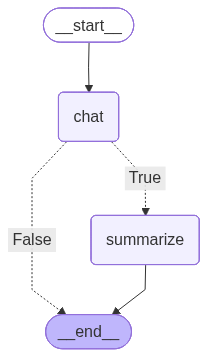

In [13]:
graph = StateGraph(ChatState)

graph.add_node("chat", chat_node)
graph.add_node("summarize", summarize_conversation)

graph.add_edge(START, "chat")

graph.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

graph.add_edge("summarize", "__end__")

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [16]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = workflow.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [17]:
run_turn('what is llm')

[HumanMessage(content='what is llm', additional_kwargs={}, response_metadata={}, id='3fec86ce-1fa4-4747-a960-8255097d8da8')]


{'messages': [HumanMessage(content='what is llm', additional_kwargs={}, response_metadata={}, id='3fec86ce-1fa4-4747-a960-8255097d8da8'),
  AIMessage(content='LLM stands for **Large Language Model**.\n\nIt\'s a type of **artificial intelligence (AI)** program that has been trained on an enormous amount of text data to understand, generate, and process human language in a highly sophisticated way.\n\nHere\'s a breakdown of what that means:\n\n1.  **Large:**\n    *   **Data:** LLMs are trained on truly massive datasets of text and code – billions, even trillions, of words from books, articles, websites, conversations, code repositories, etc.\n    *   **Parameters:** They have billions or even trillions of "parameters," which are the internal variables the model adjusts during training to learn patterns and relationships in the data. More parameters generally mean a more complex and capable model.\n\n2.  **Language:**\n    *   Their primary function revolves around human language. They le

In [18]:
run_turn('what is deep learning')

[HumanMessage(content='what is llm', additional_kwargs={}, response_metadata={}, id='3fec86ce-1fa4-4747-a960-8255097d8da8'), AIMessage(content='LLM stands for **Large Language Model**.\n\nIt\'s a type of **artificial intelligence (AI)** program that has been trained on an enormous amount of text data to understand, generate, and process human language in a highly sophisticated way.\n\nHere\'s a breakdown of what that means:\n\n1.  **Large:**\n    *   **Data:** LLMs are trained on truly massive datasets of text and code – billions, even trillions, of words from books, articles, websites, conversations, code repositories, etc.\n    *   **Parameters:** They have billions or even trillions of "parameters," which are the internal variables the model adjusts during training to learn patterns and relationships in the data. More parameters generally mean a more complex and capable model.\n\n2.  **Language:**\n    *   Their primary function revolves around human language. They learn grammar, sy

{'messages': [HumanMessage(content='what is llm', additional_kwargs={}, response_metadata={}, id='3fec86ce-1fa4-4747-a960-8255097d8da8'),
  AIMessage(content='LLM stands for **Large Language Model**.\n\nIt\'s a type of **artificial intelligence (AI)** program that has been trained on an enormous amount of text data to understand, generate, and process human language in a highly sophisticated way.\n\nHere\'s a breakdown of what that means:\n\n1.  **Large:**\n    *   **Data:** LLMs are trained on truly massive datasets of text and code – billions, even trillions, of words from books, articles, websites, conversations, code repositories, etc.\n    *   **Parameters:** They have billions or even trillions of "parameters," which are the internal variables the model adjusts during training to learn patterns and relationships in the data. More parameters generally mean a more complex and capable model.\n\n2.  **Language:**\n    *   Their primary function revolves around human language. They le

In [19]:
run_turn('what is machine learning')

[HumanMessage(content='what is llm', additional_kwargs={}, response_metadata={}, id='3fec86ce-1fa4-4747-a960-8255097d8da8'), AIMessage(content='LLM stands for **Large Language Model**.\n\nIt\'s a type of **artificial intelligence (AI)** program that has been trained on an enormous amount of text data to understand, generate, and process human language in a highly sophisticated way.\n\nHere\'s a breakdown of what that means:\n\n1.  **Large:**\n    *   **Data:** LLMs are trained on truly massive datasets of text and code – billions, even trillions, of words from books, articles, websites, conversations, code repositories, etc.\n    *   **Parameters:** They have billions or even trillions of "parameters," which are the internal variables the model adjusts during training to learn patterns and relationships in the data. More parameters generally mean a more complex and capable model.\n\n2.  **Language:**\n    *   Their primary function revolves around human language. They learn grammar, sy

{'messages': [HumanMessage(content='what is llm', additional_kwargs={}, response_metadata={}, id='3fec86ce-1fa4-4747-a960-8255097d8da8'),
  AIMessage(content='LLM stands for **Large Language Model**.\n\nIt\'s a type of **artificial intelligence (AI)** program that has been trained on an enormous amount of text data to understand, generate, and process human language in a highly sophisticated way.\n\nHere\'s a breakdown of what that means:\n\n1.  **Large:**\n    *   **Data:** LLMs are trained on truly massive datasets of text and code – billions, even trillions, of words from books, articles, websites, conversations, code repositories, etc.\n    *   **Parameters:** They have billions or even trillions of "parameters," which are the internal variables the model adjusts during training to learn patterns and relationships in the data. More parameters generally mean a more complex and capable model.\n\n2.  **Language:**\n    *   Their primary function revolves around human language. They le

In [20]:
run_turn('what is Transformers')

[HumanMessage(content='what is llm', additional_kwargs={}, response_metadata={}, id='3fec86ce-1fa4-4747-a960-8255097d8da8'), AIMessage(content='LLM stands for **Large Language Model**.\n\nIt\'s a type of **artificial intelligence (AI)** program that has been trained on an enormous amount of text data to understand, generate, and process human language in a highly sophisticated way.\n\nHere\'s a breakdown of what that means:\n\n1.  **Large:**\n    *   **Data:** LLMs are trained on truly massive datasets of text and code – billions, even trillions, of words from books, articles, websites, conversations, code repositories, etc.\n    *   **Parameters:** They have billions or even trillions of "parameters," which are the internal variables the model adjusts during training to learn patterns and relationships in the data. More parameters generally mean a more complex and capable model.\n\n2.  **Language:**\n    *   Their primary function revolves around human language. They learn grammar, sy

{'messages': [HumanMessage(content='what is Transformers', additional_kwargs={}, response_metadata={}, id='eba4b91f-38f3-4105-b3b0-1e584bdb42cb'),
  AIMessage(content='A **Transformer** is a revolutionary **neural network architecture** that has completely reshaped the field of **Natural Language Processing (NLP)** and, more broadly, deep learning for sequential data. It was introduced in 2017 by Google researchers in their seminal paper "Attention Is All You Need."\n\nIt\'s the foundational technology behind most modern Large Language Models (LLMs) like OpenAI\'s GPT series, Google\'s BERT and Gemini, Meta\'s Llama, and Anthropic\'s Claude.\n\nTo understand Transformers, it\'s helpful to know what came before and the problems they solved:\n\n### Background: Limitations of Previous Architectures for Sequence Data\n\nBefore Transformers, **Recurrent Neural Networks (RNNs)** and their variants like **LSTMs (Long Short-Term Memory)** were the state-of-the-art for processing sequences (lik